In [1]:
import numpy as np
import pandas as pd

In [2]:
data_nlp = pd.read_csv("../Output/Pred Input/NLP_train.csv")
data_ses = pd.read_csv("../Output/Pred Input/SES_train.csv")

data_combined = pd.merge(data_nlp, data_ses, on='LSOA21CD', how='left')

sbert_cols = [str(i) for i in range(0, 384)]
topic_cols = [col for col in data_nlp.columns if col.startswith("topic_")]
topic_cols_sorted = sorted(topic_cols, key=lambda x: int(x.split("_")[1]))
top_50 = topic_cols_sorted[:50]
top_100 = topic_cols_sorted[:100]
top_200 = topic_cols_sorted[:200]
top_500 = topic_cols_sorted[:500]
ses_cols = [col for col in data_ses.columns if col != 'LSOA21CD']


X_ses = data_ses.drop(columns=['LSOA21CD'])
X_sbert = data_combined.drop(columns=['LSOA21CD'] + ses_cols + topic_cols)
X_topic = data_combined.drop(columns=['LSOA21CD'] + ses_cols + sbert_cols)
X_topic50 = data_nlp[top_50]
X_topic100 = data_nlp[top_100]
X_topic200 = data_nlp[top_200]
X_topic500 = data_nlp[top_500]
X_nlp = data_combined.drop(columns=['LSOA21CD'] + ses_cols)
X_topic_ses = data_combined.drop(columns=['LSOA21CD'] + sbert_cols)
X_sbert_ses = data_combined.drop(columns=['LSOA21CD'] + topic_cols)
X_all = data_combined.drop(columns=['LSOA21CD'])

In [3]:
import torch

y = torch.load("../Output/Pred Input/y_train_5.pt")
y = y.numpy()

In [4]:
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='xgboost')

In [28]:
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# Collect available feature sets from the current namespace
CANDIDATE_NAMES = [
    "X_ses", "X_sbert", "X_topic", "X_topic50", "X_topic100", "X_topic200", "X_topic500",
    "X_nlp", "X_topic_ses", "X_sbert_ses", "X_all"
]

ns = globals()
feature_sets = {}
for name in CANDIDATE_NAMES:
    if name in ns and ns[name] is not None:
        feature_sets[name] = ns[name]

if "y" not in ns:
    raise RuntimeError("y not found in namespace. Please define your target labels as 'y'.")

y_series = pd.Series(y).reset_index(drop=True)  # defensive copy

# Ensure feature matrices are DataFrames with aligned indices
for k, X in list(feature_sets.items()):
    if not isinstance(X, pd.DataFrame):
        try:
            X = pd.DataFrame(X)
        except Exception as e:
            print(f"[WARN] Could not convert {k} to DataFrame: {e}. Dropping.")
            feature_sets.pop(k)
            continue
    # reset index to align with y by position
    feature_sets[k] = X.reset_index(drop=True)

if not feature_sets:
    raise RuntimeError("No candidate feature sets found. Make sure at least one X_* exists.")

print(f"Discovered {len(feature_sets)} feature sets:")
for k, X in feature_sets.items():
    print(f"  - {k:12s}: shape={tuple(X.shape)}")

import random
random.seed(42)
SEEDS = random.sample(range(10000), 10)
TEST_SIZE = 0.2

# Baseline XGBoost config (multi-class, no extensive tuning)
def make_xgb(num_classes):
    return XGBClassifier(
        objective="multi:softprob",
        num_class=int(num_classes),
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42,
    )

results_rows = []
per_run_scores = {}  # store per-run metrics for boxplots, e.g., per_run_scores[(name, metric)] = [vals]

for name, X in feature_sets.items():
    acc_list, f1_macro_list, f1_weighted_list = [], [], []

    # Sanity: drop any columns with all-NaN
    Xc = X.dropna(axis=1, how="all")

    for seed in SEEDS:
        X_train_, X_val_, y_train_, y_val_ = train_test_split(
            Xc, y_series, test_size=TEST_SIZE, random_state=seed, stratify=y_series
        )
        model = make_xgb(num_classes=len(np.unique(y_series)))
        model.fit(X_train_, y_train_)

        y_pred_ = model.predict(X_val_)
        acc = accuracy_score(y_val_, y_pred_)
        f1_ma = f1_score(y_val_, y_pred_, average="macro", zero_division=0)
        f1_wt = f1_score(y_val_, y_pred_, average="weighted", zero_division=0)

        acc_list.append(acc)
        f1_macro_list.append(f1_ma)
        f1_weighted_list.append(f1_wt)
    
    print(f"Training process of {name} is completed.")
    
    # aggregate
    def agg(arr):
        return float(np.mean(arr)), float(np.std(arr))

    acc_mean, acc_std = agg(acc_list)
    f1ma_mean, f1ma_std = agg(f1_macro_list)
    f1wt_mean, f1wt_std = agg(f1_weighted_list)

    results_rows.append({
        "feature_set": name,
        "acc_mean": acc_mean, "acc_std": acc_std,
        "f1_macro_mean": f1ma_mean, "f1_macro_std": f1ma_std,
        "f1_weighted_mean": f1wt_mean, "f1_weighted_std": f1wt_std,
        "n_features": Xc.shape[1]
    })

    per_run_scores[(name, "Accuracy")] = acc_list
    per_run_scores[(name, "Macro-F1")] = f1_macro_list
    per_run_scores[(name, "Weighted-F1")] = f1_weighted_list

results_df = pd.DataFrame(results_rows).sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
print("\n=== Summary (sorted by Macro-F1 mean) ===")
print(results_df)

# Save results
os.makedirs("../Output/Performance", exist_ok=True)
results_path = os.path.join("../Output/Performance", "xgb_baseline_benchmark_results.csv")
results_df.to_csv(results_path, index=False)
print(f"\nSaved results to: {results_path}")

Discovered 11 feature sets:
  - X_ses       : shape=(4994, 84)
  - X_sbert     : shape=(4994, 385)
  - X_topic     : shape=(4994, 1175)
  - X_topic50   : shape=(4994, 50)
  - X_topic100  : shape=(4994, 100)
  - X_topic200  : shape=(4994, 200)
  - X_topic500  : shape=(4994, 500)
  - X_nlp       : shape=(4994, 1559)
  - X_topic_ses : shape=(4994, 1259)
  - X_sbert_ses : shape=(4994, 469)
  - X_all       : shape=(4994, 1643)
Training process of X_ses is completed.
Training process of X_sbert is completed.
Training process of X_topic is completed.
Training process of X_topic50 is completed.
Training process of X_topic100 is completed.
Training process of X_topic200 is completed.
Training process of X_topic500 is completed.
Training process of X_nlp is completed.
Training process of X_topic_ses is completed.
Training process of X_sbert_ses is completed.
Training process of X_all is completed.

=== Summary (sorted by Macro-F1 mean) ===
    feature_set  acc_mean   acc_std  f1_macro_mean  f1_m

In [29]:
import os

# Global settings
SAVE_DIR = "Output"  # Directory for saving figures
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_FIG = True      # Toggle saving figures (True = save, False = only show)

C:\Users\wbwha\AppData\Local\Temp\ipykernel_7564\1950614915.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


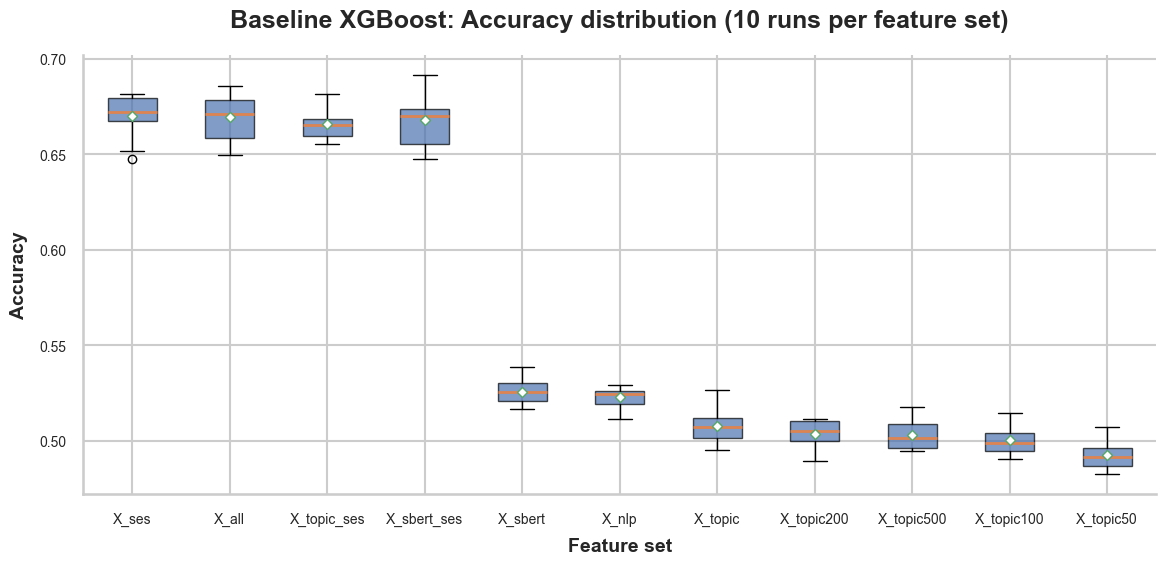

C:\Users\wbwha\AppData\Local\Temp\ipykernel_7564\1950614915.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


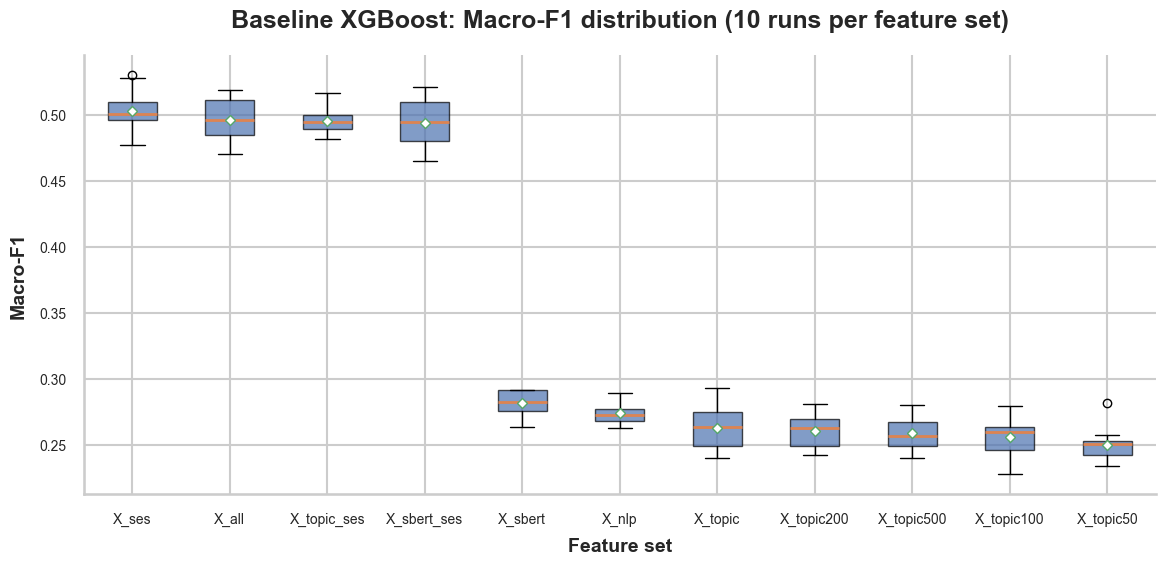

C:\Users\wbwha\AppData\Local\Temp\ipykernel_7564\1950614915.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


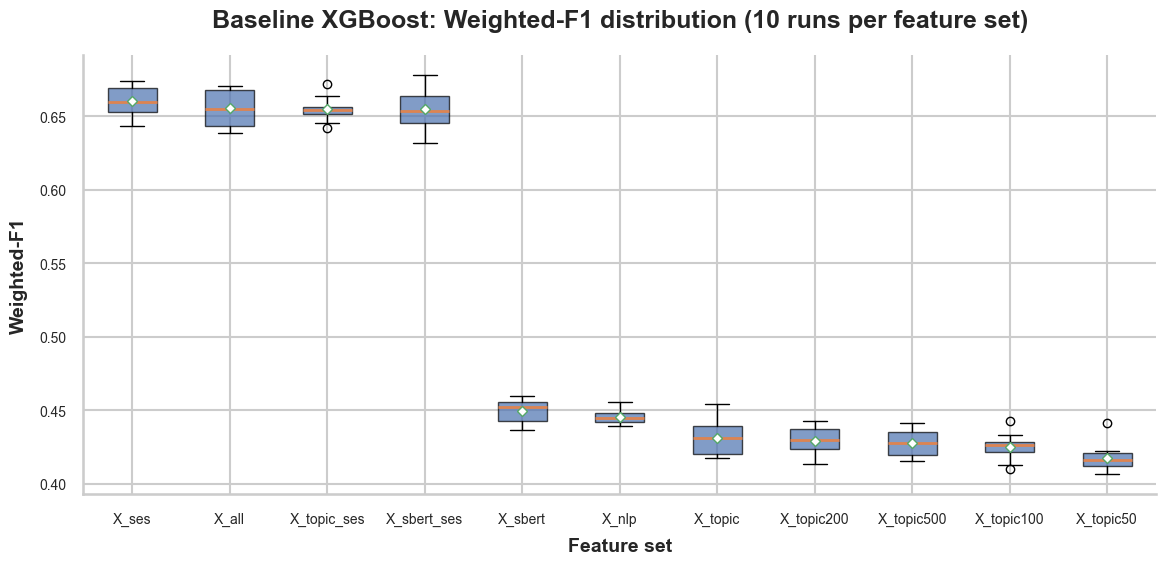

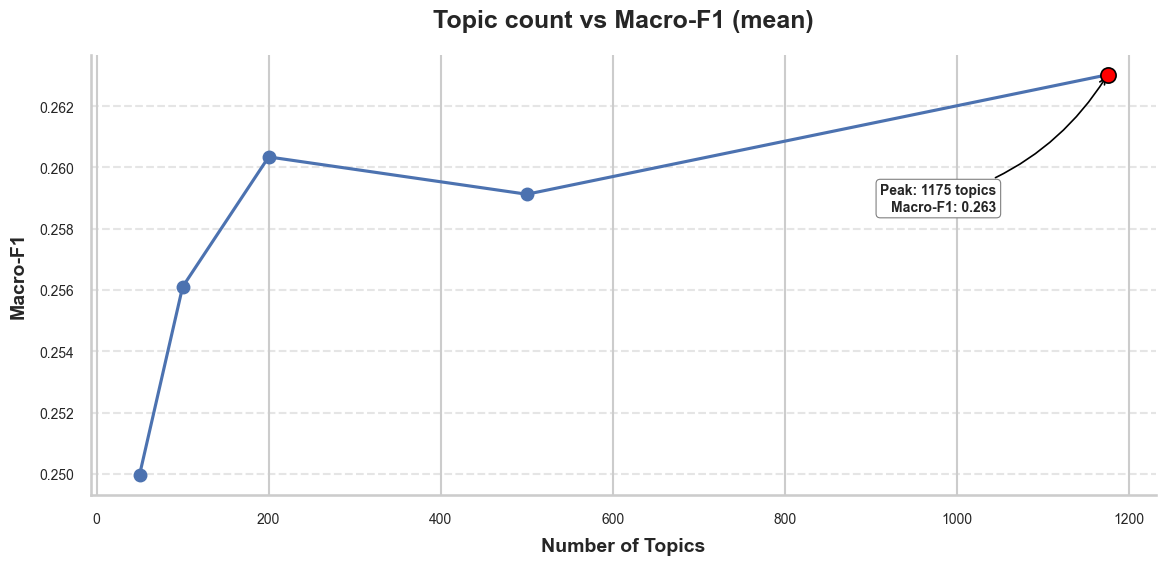

In [30]:
# Visualization

import textwrap

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

# Set a clean, readable theme using seaborn
sns.set_theme(context="talk", style="whitegrid")

# Apply consistent matplotlib style tweaks
plt.rcParams.update({
    "axes.spines.top": False,      # Remove top border
    "axes.spines.right": False,    # Remove right border
    "axes.titleweight": "bold",    # Bold titles
    "axes.titlepad": 20,           # Padding for titles
    "axes.labelpad": 8,            # Padding for axis labels
    "figure.autolayout": False,    # We'll control layout manually
})

def savefig(path):
    """Helper: Save figure if SAVE_FIG is True."""
    if SAVE_FIG:
        plt.savefig(path, dpi=300, bbox_inches="tight")

results_df = pd.read_csv("../Output/Performance/xgb_baseline_benchmark_results.csv")

# Sort feature sets by Macro-F1 mean
if "f1_macro_mean" in results_df.columns and "feature_set" in results_df.columns:
    results_df = results_df.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)

# Preserve ordering for consistent plots
order = results_df["feature_set"].tolist()

# Convert per_run_scores to long-form DataFrame for seaborn/matplotlib
long_rows = []
for (fs, metric), vals in per_run_scores.items():
    for v in vals:
        long_rows.append({"feature_set": fs, "metric": metric, "score": v})
long_df = pd.DataFrame(long_rows)
long_df["feature_set"] = pd.Categorical(long_df["feature_set"], categories=order, ordered=True)

# Helper: Wrap long labels to avoid overlap
def wrap_labels(labels, width=16):
    return ["\n".join(textwrap.wrap(str(lbl), width=width, break_long_words=False)) for lbl in labels]


# 1) Bar chart with error bars (Macro-F1 mean ± std)
# fig, ax = plt.subplots(figsize=(12, 6))
# ax.set_title("Baseline XGBoost: Macro-F1 across feature sets (mean ± std)")

# bars = ax.bar(
#     x=np.arange(len(order)),
#     height=results_df["f1_macro_mean"].values,
#     yerr=results_df["f1_macro_std"].values,
#     capsize=4
# )

# # Annotate bars with mean ± std values
# for rect, mean, std in zip(bars, results_df["f1_macro_mean"], results_df["f1_macro_std"]):
#     ax.annotate(f"{mean:.3f}±{std:.3f}",
#                 xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
#                 xytext=(0, 6), textcoords="offset points",
#                 ha="center", va="bottom", fontsize=8)

# ax.set_ylabel("Macro-F1", fontsize=14, fontweight='bold')
# ax.set_xlabel("Feature set", fontsize=14, fontweight='bold')
# ax.set_xticks(np.arange(len(order)))
# ax.set_xticklabels(wrap_labels(order, width=18), rotation=0, ha="center")
# ax.tick_params(axis='both', labelsize=10)
# ax.set_ylim(0, min(1.0, max(0.05 + results_df["f1_macro_mean"].max() + results_df["f1_macro_std"].max(), 0.6)))

# plt.tight_layout()
# savefig(os.path.join(SAVE_DIR, "xgb_macro_f1_bar_mean_std.png"))
# plt.show()

# 2) Boxplots for all three metrics

for metric in ["Accuracy", "Macro-F1", "Weighted-F1"]:
    subset = long_df[long_df["metric"] == metric].copy()
    groups = [g["score"].values for _, g in subset.groupby("feature_set", observed=True)]
    labels = [k for k, _ in subset.groupby("feature_set", observed=True)]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(f"Baseline XGBoost: {metric} distribution ({len(groups[0])} runs per feature set)")
    bp = ax.boxplot(
        groups,
        labels=wrap_labels(labels, width=18),
        showmeans=True,  # Show diamond marker for mean
        meanprops=dict(marker='D', markersize=5, markerfacecolor='white'),
        patch_artist=True
    )

    # Light styling
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set_linewidth(2)

    ax.set_xlabel("Feature set", fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    savefig(os.path.join(SAVE_DIR, f"xgb_{metric.lower().replace('-', '_')}_box.png"))
    plt.show()


# 3) Topic count vs Macro-F1 curve (for topic-based sets)

topic_sizes = [("X_topic50", 50), ("X_topic100", 100), ("X_topic200", 200), ("X_topic500", 500), ("X_topic", 1175)]
curve_points = []
for name, k in topic_sizes:
    row = results_df[results_df["feature_set"] == name]
    if not row.empty:
        curve_points.append((k, float(row["f1_macro_mean"].iloc[0])))

if curve_points:
    curve_points = sorted(curve_points, key=lambda x: x[0])
    ks, scores = zip(*curve_points)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(ks, scores, marker="o")
    ax.set_title("Topic count vs Macro-F1 (mean)")
    ax.set_xlabel("Number of Topics", fontsize=14, fontweight='bold')
    ax.set_ylabel("Macro-F1", fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

    # Find peak point index
    best_i = int(np.argmax(scores))
    peak_x = ks[best_i]
    peak_y = scores[best_i]

    # Highlight peak point with a larger, outlined marker
    ax.scatter(peak_x, peak_y, s=120, color="red", edgecolor="black", linewidth=1.2, zorder=5)

    # Decide text position automatically (left or right of point)
    offset_x = 10 if peak_x < max(ks) else -80  # Shift left if peak is at the right edge
    offset_y = -100

    # Annotate with arrow and bold text
    ax.annotate(
        f"Peak: {peak_x} topics\nMacro-F1: {peak_y:.3f}",
        xy=(peak_x, peak_y),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        ha="left" if offset_x > 0 else "right",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.2,
            color="black",
            connectionstyle="arc3,rad=0.2"  # Slight curve
        )
    )

    plt.tight_layout()
    savefig(os.path.join(SAVE_DIR, "xgb_topiccount_vs_macro_f1.png"))
    plt.show()

# best_name = results_df.iloc[0]["feature_set"]
# print(f"\nBest feature set by Macro-F1: {best_name}")
# X_best = feature_sets[best_name].dropna(axis=1, how="all").reset_index(drop=True)

In [31]:
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
# Define parameter grid for GridSearchCV
param_grid = {
    'max_depth': range(3, 17, 2),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': range(50, 210, 10)
}

# Initialize XGBoost classifier
xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Run grid search with 3-fold cross-validation
print("Running grid search...")
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    # n_jobs=-1
)

X_train, X_val, y_train, y_val = train_test_split(X_ses, y, test_size=0.2, stratify=y, random_state=42)

grid_search.fit(X_train , y_train)

# Output the best model and evaluate on validation set
best_model = grid_search.best_estimator_

print("\nBest parameters found:")
print(grid_search.best_params_)

print("\nEvaluating best model on validation set...")
y_pred = best_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Running grid search...
Fitting 5 folds for each of 336 candidates, totalling 1680 fits

Best parameters found:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150}

Evaluating best model on validation set...
Accuracy: 0.6776776776776777
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91       507
           1       0.52      0.38      0.44       128
           2       0.41      0.36      0.38       108
           3       0.47      0.48      0.48       144
           4       0.35      0.38      0.36       112

    accuracy                           0.68       999
   macro avg       0.53      0.51      0.51       999
weighted avg       0.66      0.68      0.67       999



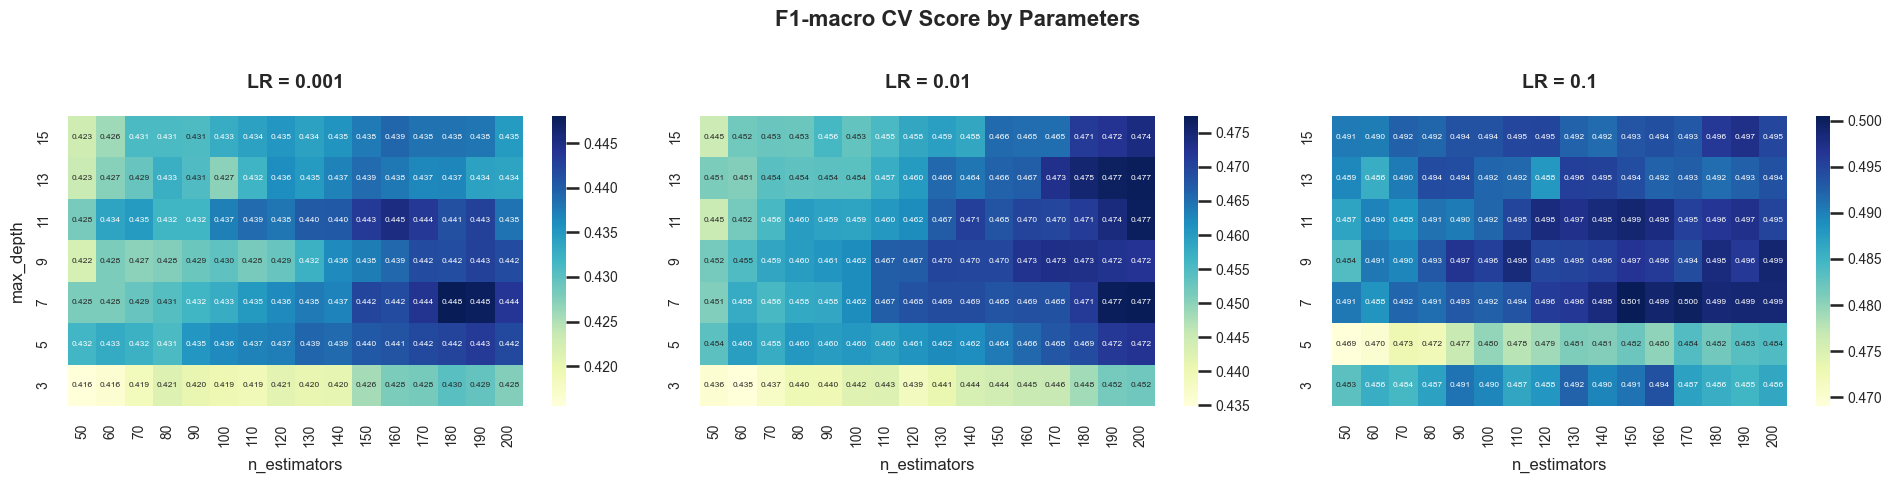

In [32]:
import os

import textwrap

import seaborn as sns
import matplotlib.pyplot as plt

# Global plot style settings
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# Ensure output directory exists
import os
os.makedirs("Output", exist_ok=True)

# 1) Heatmaps of mean CV score by LR

# Convert params to numeric for sorting
results_df_ = pd.DataFrame(grid_search.cv_results_)

results_df_["param_max_depth"] = results_df_["param_max_depth"].astype(float)
results_df_["param_n_estimators"] = results_df_["param_n_estimators"].astype(float)
results_df_["param_learning_rate"] = results_df_["param_learning_rate"].astype(float)

# Get sorted unique LRs
lr_values = sorted(results_df_["param_learning_rate"].unique())

# Create subplots: one row, len(lr_values) columns
fig, axes = plt.subplots(1, len(lr_values), figsize=(6.5 * len(lr_values), 5), sharey=False)

for idx, lr in enumerate(lr_values):
    subset = results_df_[results_df_["param_learning_rate"] == lr]
    pivot = subset.pivot_table(
        index="param_max_depth",
        columns="param_n_estimators",
        values="mean_test_score",
        aggfunc="mean"
    )
    pivot.index = pivot.index.astype(int)
    pivot.columns = pivot.columns.astype(int)

    # Create heatmap with smaller annotation font size
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        annot_kws={"size": 6},  # smaller font for numbers inside cells
        ax=axes[idx]
    )
    axes[idx].invert_yaxis()
    axes[idx].set_title(f"LR = {lr:g}", fontsize=14)
    axes[idx].set_xlabel("n_estimators", fontsize=12)
    if idx == 0:
        axes[idx].set_ylabel("max_depth", fontsize=12)
    else:
        axes[idx].set_ylabel("")

plt.suptitle("F1-macro CV Score by Parameters", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Output/heatmap_lr_side_by_side.png", dpi=200, bbox_inches="tight")
plt.show()

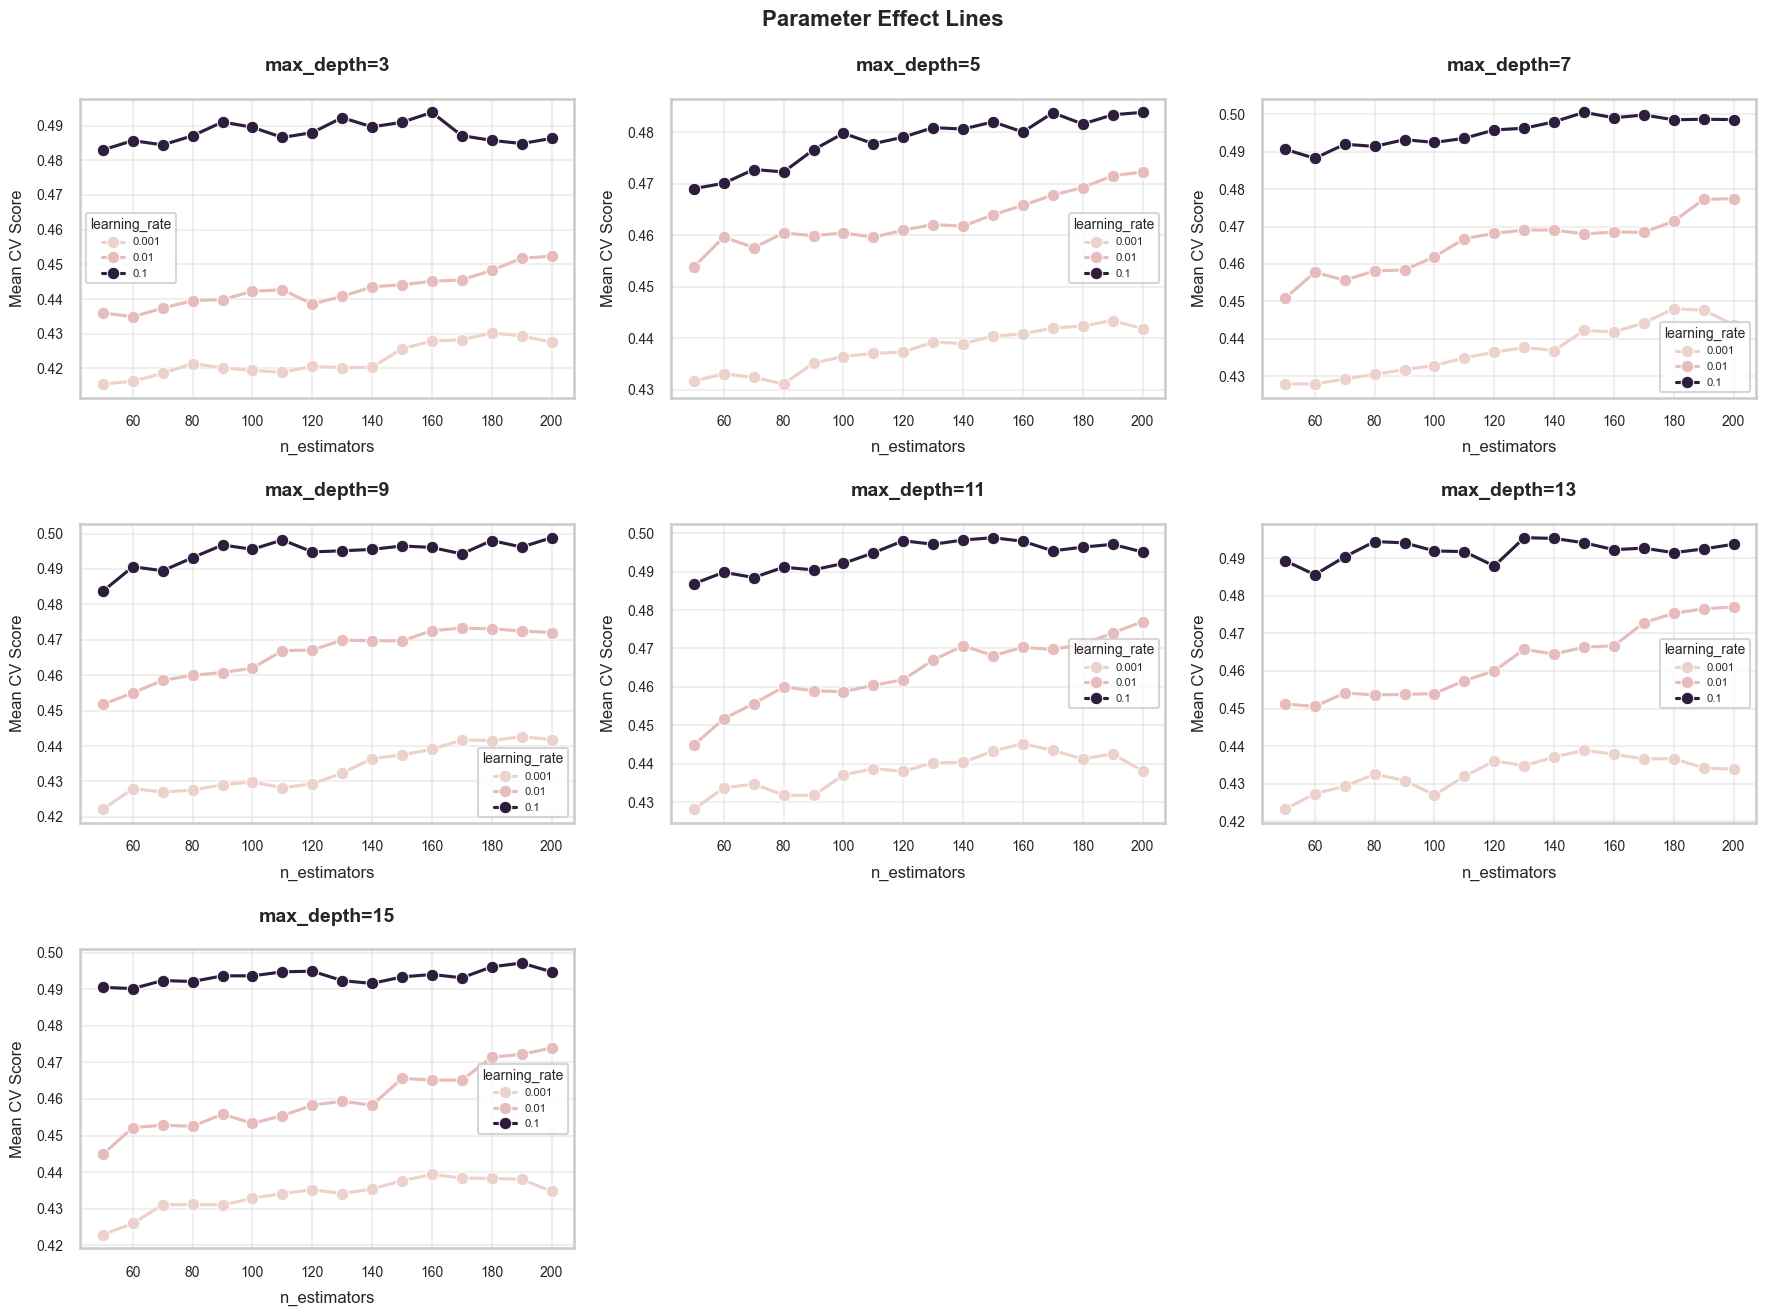

In [33]:
# 2) Parameter effect line plots

# Average performance over other parameters
df_avg = results_df_.groupby(
    ["param_n_estimators", "param_learning_rate", "param_max_depth"],
    as_index=False
)["mean_test_score"].mean()

# Get sorted unique max_depth values for small multiples
depth_values = sorted(df_avg["param_max_depth"].unique())
n = len(depth_values)
cols = min(n, 3)
rows = (n + cols - 1) // cols

plt.figure(figsize=(6*cols, 4.5*rows))
for i, d in enumerate(depth_values, 1):
    ax = plt.subplot(rows, cols, i)
    data_d = df_avg[df_avg["param_max_depth"] == d]
    sns.lineplot(
        data=data_d,
        x="param_n_estimators",
        y="mean_test_score",
        hue="param_learning_rate",
        marker="o",
        ax=ax
    )
    ax.set_title(f"max_depth={int(d)}", fontsize=14)
    ax.set_xlabel("n_estimators", fontsize=12)
    ax.set_ylabel("Mean CV Score", fontsize=12)
    ax.legend(title="learning_rate",
              prop={'size': 8}, 
              title_fontsize=10)
    ax.grid(True, alpha=0.3)
plt.suptitle("Parameter Effect Lines", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Output/param_effect_lines.png", dpi=200)
plt.show()

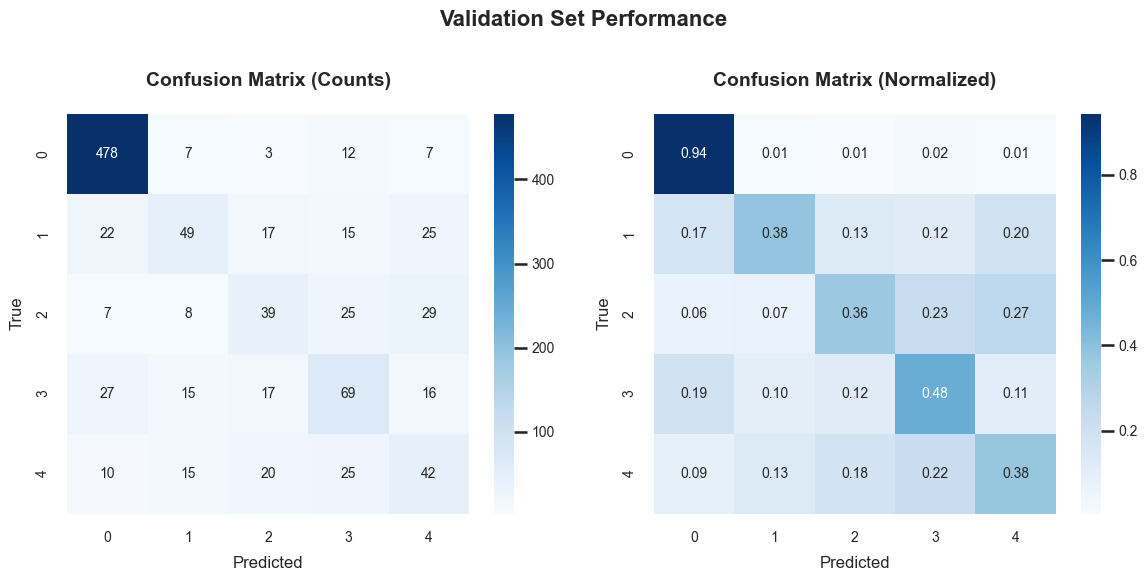

In [34]:
# 3) Confusion matrix on validation set
from sklearn.metrics import confusion_matrix

labels = np.unique(y_val)  # unique class labels
cm = confusion_matrix(y_val, y_pred, labels=labels)
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

# Create 1 row, 2 columns subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Raw counts ---
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 10},
    ax=axes[0]
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (Counts)", fontsize=14)

# --- Normalized ---
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 10},
    ax=axes[1]
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (Normalized)", fontsize=14)

plt.suptitle("Validation Set Performance", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Output/confusion_matrices_side_by_side.png", dpi=200, bbox_inches="tight")
plt.show()

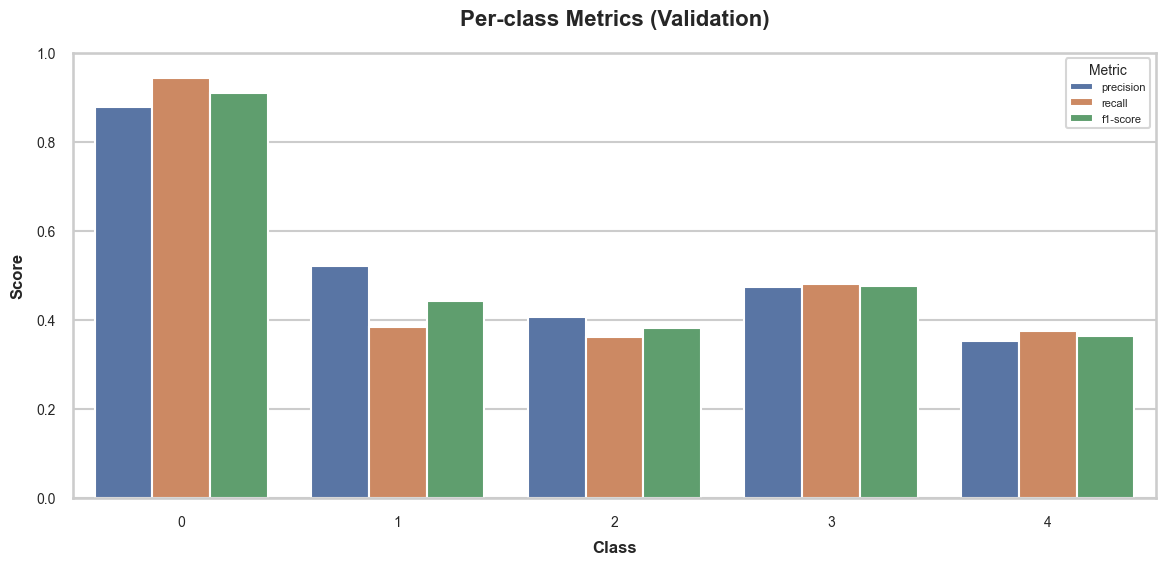

In [35]:
# 4) Classification report bar chart

report = classification_report(y_val, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).T.reset_index().rename(columns={"index": "label"})

# Keep only per-class rows (exclude accuracy/macro/weighted)
df_per_class = df_report[~df_report["label"].isin(["accuracy", "macro avg", "weighted avg"])]
df_per_class = df_per_class[["label", "precision", "recall", "f1-score"]]

# Melt to long format for seaborn barplot
df_melt = df_per_class.melt(id_vars="label", var_name="metric", value_name="score")

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melt, x="label", y="score", hue="metric")
plt.ylim(0, 1.0)
plt.xlabel("Class", fontweight='bold')
plt.ylabel("Score", fontweight='bold')
plt.title("Per-class Metrics (Validation)")

# Adjust legend size
ax.legend(
    title="Metric",
    prop={'size': 8},
    title_fontsize=10
)

plt.tight_layout()
plt.savefig("Output/class_report_bars.png", dpi=200)
plt.show()

Common features in top-10 for all metrics: {'Single family household: Married or civil partnership couple: No children', 'Economically active: Unemployed', '7 rooms', 'Economically inactive: Long-term sick or disabled'}


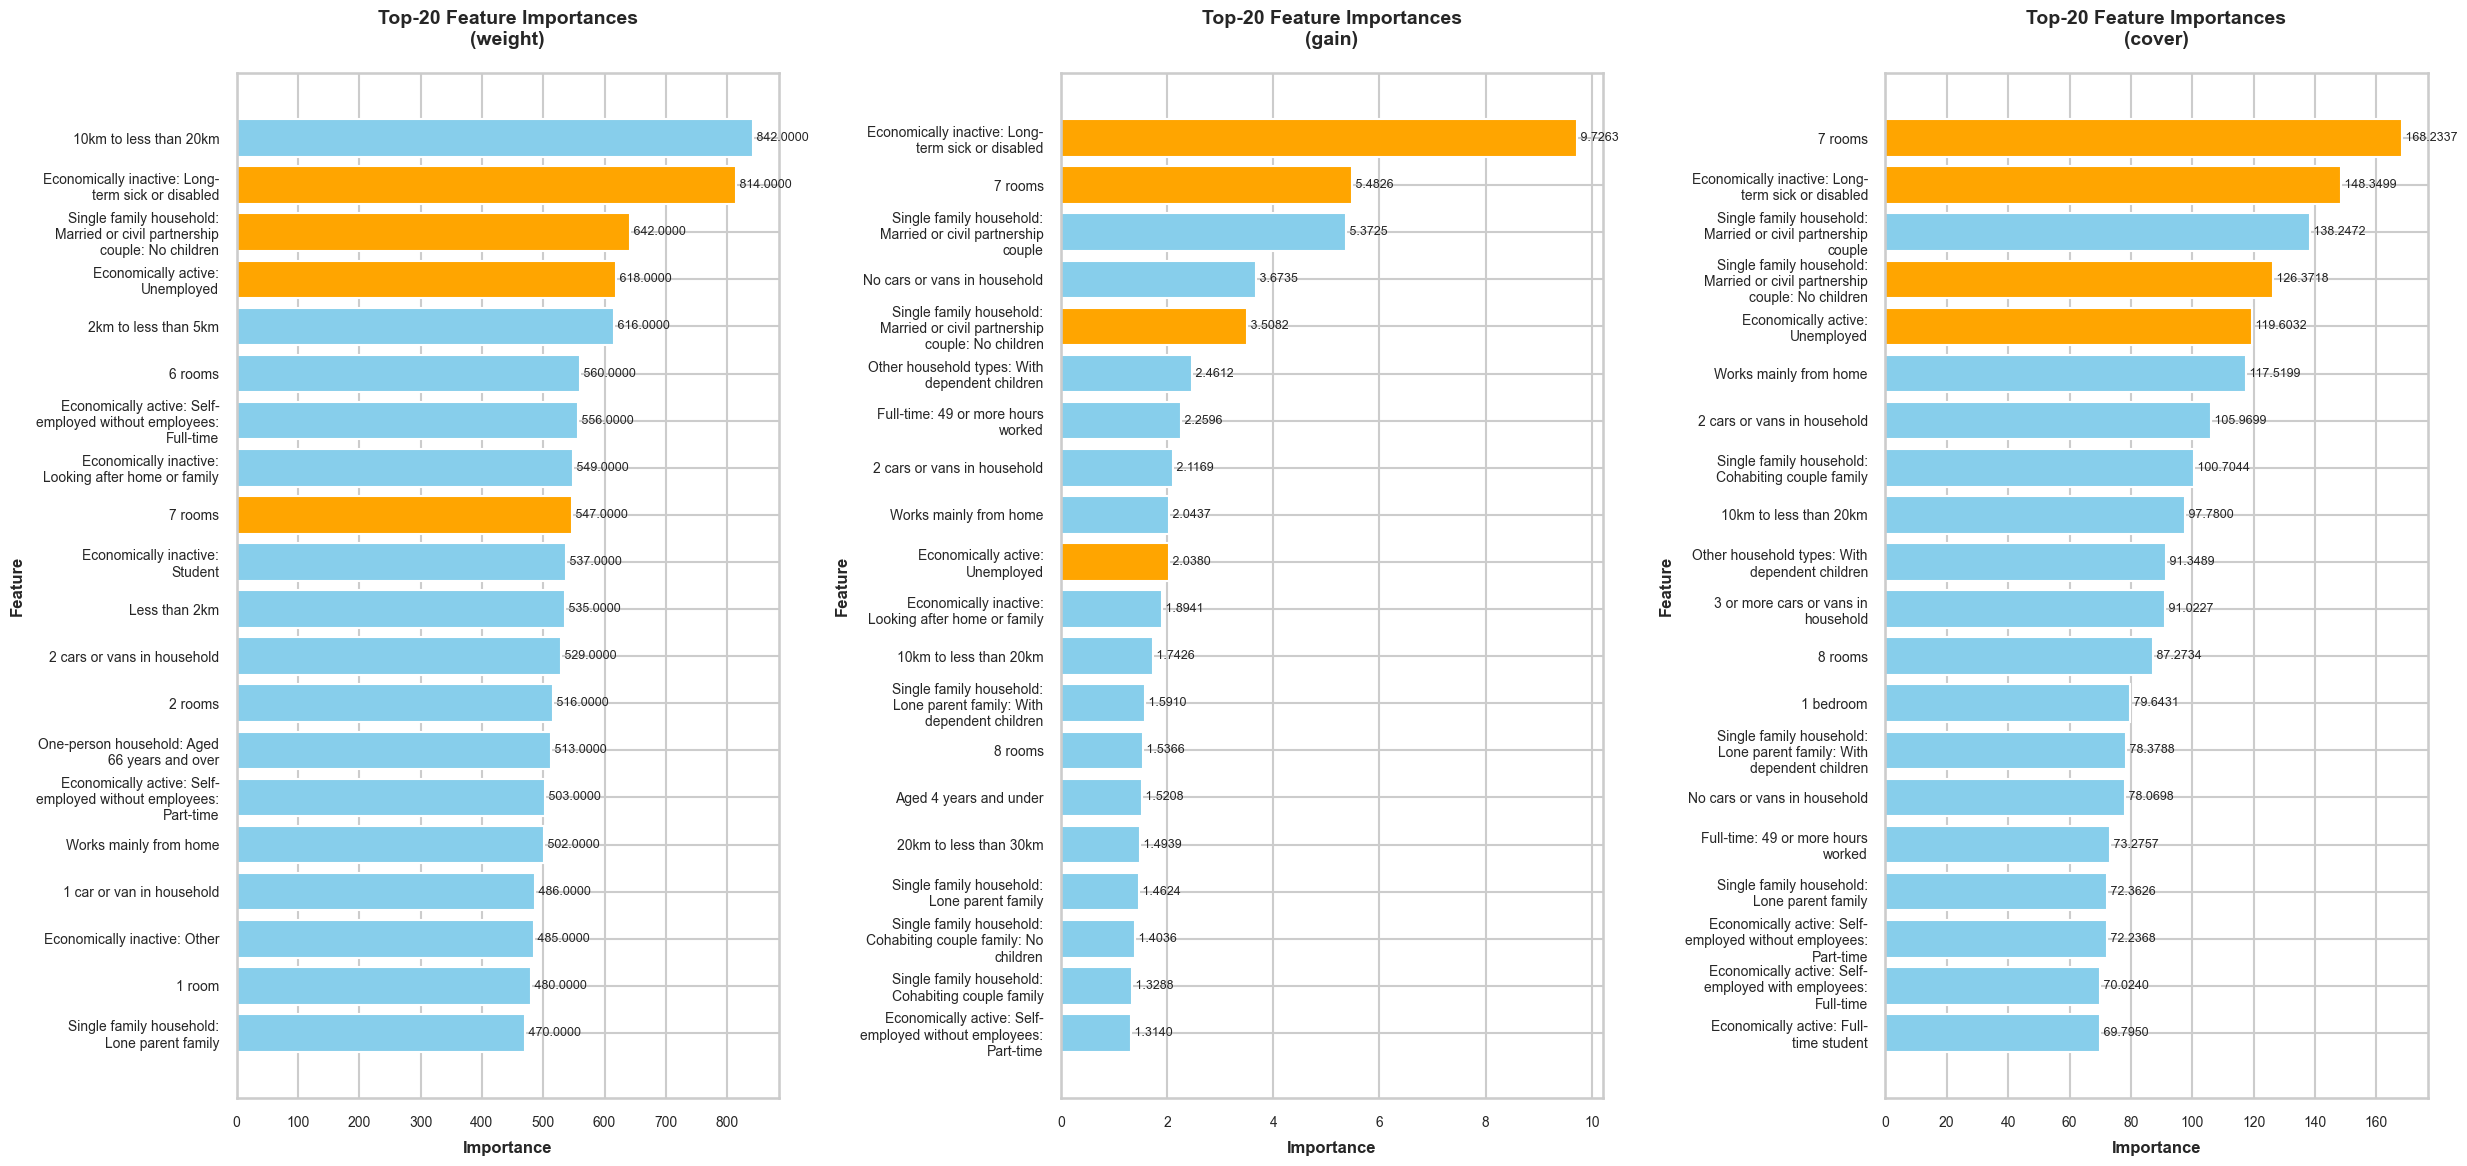

In [36]:
# 5) Feature importance from XGBoost model

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

importance_types = ["weight", "gain", "cover"]

# Step 1 — Collect top-10 features for each importance type
top10_sets = {}
booster = best_model.get_booster()

for imp_type in importance_types:
    score_dict = booster.get_score(importance_type=imp_type)
    if score_dict:
        imp_df = (
            pd.DataFrame({"feature": list(score_dict.keys()),
                          "importance": list(score_dict.values())})
            .sort_values("importance", ascending=False)
        )
        top10_sets[imp_type] = set(imp_df.head(10)["feature"])
    else:
        top10_sets[imp_type] = set()

# Step 2 — Find features common to all three sets
common_top10 = set.intersection(*top10_sets.values())
print(f"Common features in top-10 for all metrics: {common_top10}")

# Step 3 — Create subplots
fig, axes = plt.subplots(1, 3, figsize=(25, 12), sharey=False)

for idx, imp_type in enumerate(importance_types):
    try:
        score_dict = booster.get_score(importance_type=imp_type)
        if not score_dict:
            print(f"No importance data for {imp_type}")
            continue

        # Prepare DataFrame
        imp_df = (
            pd.DataFrame({"feature": list(score_dict.keys()),
                          "importance": list(score_dict.values())})
            .sort_values("importance", ascending=False)
            .head(20)
            .copy()
        )

        # Wrap long feature names
        imp_df["feature_wrapped"] = [
            "\n".join(textwrap.wrap(str(f), width=28, break_long_words=False))
            for f in imp_df["feature"]
        ]

        # Color mapping: orange if in common_top10, else skyblue
        colors = [
            "orange" if f in common_top10 else "skyblue"
            for f in imp_df["feature"]
        ]

        # Plot horizontal bar chart
        ax = axes[idx]
        ax.barh(imp_df["feature_wrapped"], imp_df["importance"], color=colors)
        ax.set_title(f"Top-20 Feature Importances\n({imp_type})", fontsize=14, fontweight='bold')
        ax.set_xlabel("Importance", fontsize=12, fontweight='bold')
        ax.set_ylabel("Feature", fontsize=12, fontweight='bold')
        ax.tick_params(axis='both', labelsize=10)
        ax.invert_yaxis()

        # Annotate each bar with its importance value
        for y_pos, val in enumerate(imp_df["importance"]):
            ax.text(val, y_pos, f" {val:.4f}", va="center", ha="left", fontsize=9)

    except Exception as e:
        print(f"Could not compute {imp_type} feature importances: {e}")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "feature_importance_comparison_highlight.png"), dpi=200, bbox_inches="tight")
plt.show()

In [37]:
data_ses_pred = pd.read_csv("../Output/Pred Input/SES_pred.csv")
X_ses_pred = data_ses_pred.drop(columns=['LSOA21CD'])

y_pred_2031 = best_model.predict(X_ses_pred)

In [38]:
label_mapping_5 = {
    "Class 0 - Stable Affluent and Moderate-income": 0,
    "Class 1 - Stable Low-income": 1,
    "Class 2 - Ongoing Displacement": 2,
    "Class 3 - At Risk of Gentrification": 3,
    "Class 4 - Ongoing Gentrification": 4
}
reverse_mapping = {v: k for k, v in label_mapping_5.items()}

df_pred_2031 = pd.DataFrame({
    'LSOA21CD': data_ses_pred['LSOA21CD'].values,
    'gentrification_class': [reverse_mapping[label] for label in y_pred_2031]
})

In [39]:
df_pred_2031

,LSOA21CD,gentrification_class
0,E01000001,Class 0 - Stable Affluent and Moderate-income
1,E01000002,Class 0 - Stable Affluent and Moderate-income
2,E01000003,Class 2 - Ongoing Displacement
3,E01000005,Class 1 - Stable Low-income
4,E01000006,Class 3 - At Risk of Gentrification
...,...,...
4989,E01035718,Class 0 - Stable Affluent and Moderate-income
4990,E01035719,Class 1 - Stable Low-income
4991,E01035720,Class 1 - Stable Low-income
4992,E01035721,Class 3 - At Risk of Gentrification


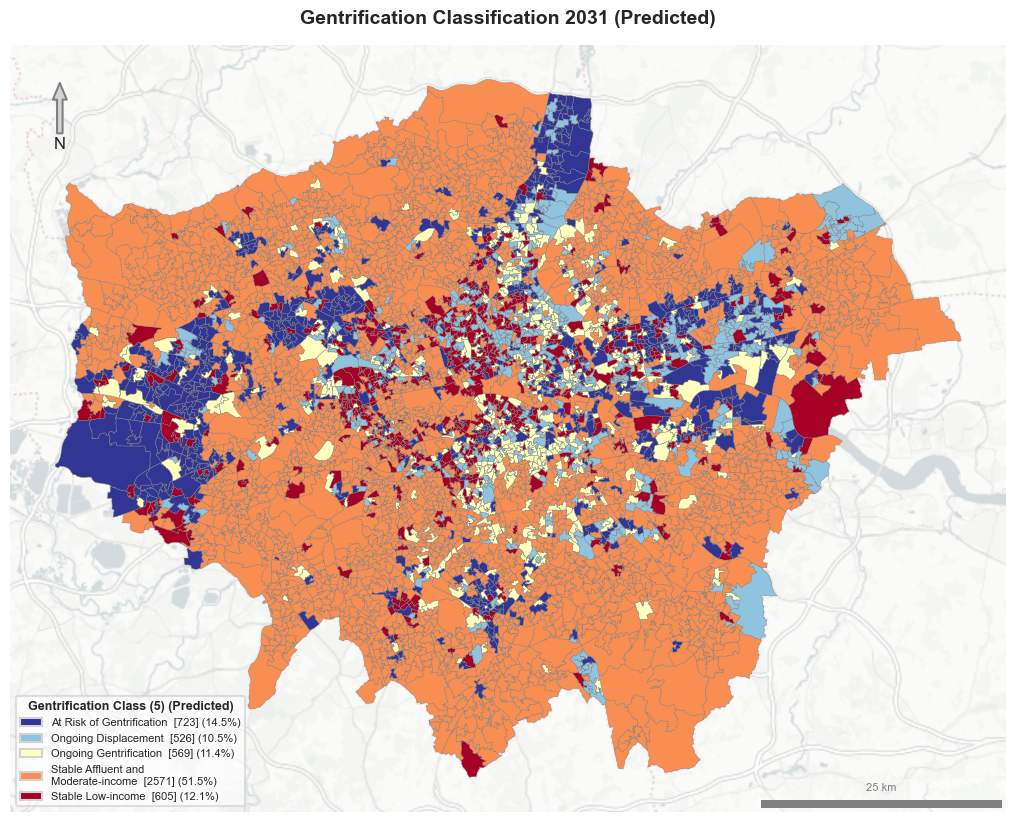

In [40]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar

import contextily as ctx

def extract_after_dash(s: str) -> str:
    """Extract the text after the first dash in the string."""
    if not isinstance(s, str):
        s = str(s)
    parts = s.split('-', 1)
    return parts[1].strip() if len(parts) > 1 else s.strip()

def wrap_label(s, width=26):
    """Wrap long text labels for better readability in legends."""
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=False))

def build_label_color_map(labels_in_order, cmap_name="RdYlBu_r"):
    """Create a discrete ordered colormap mapping labels to colors."""
    K = len(labels_in_order)
    base = plt.get_cmap(cmap_name, K)
    return {lab: base(i) for i, lab in enumerate(labels_in_order)}


# Merge predictions into base GeoDataFrame

import geopandas as gpd

# Load LSOA boundary
gdf = gpd.read_file("../Output/Geo Output/London_LSOA_2021.shp")

gdf_web = gdf.to_crs(epsg=3857).copy()

# Merge prediction DataFrame (df_pred_2031) into gdf_web
gdf_web = gdf_web.merge(df_pred_2031, on="LSOA21CD", how="left")

# Create label using the part after the dash
gdf_web["label_after"] = gdf_web["gentrification_class"].astype(str).apply(extract_after_dash)

# Build color mapping based on the labels present in the predictions
labels_in_order = sorted(pd.unique(gdf_web["label_after"].dropna()))
label2color = build_label_color_map(labels_in_order, cmap_name="RdYlBu_r")

# Map labels to palette indices for plotting
lab2idx = {lab: i for i, lab in enumerate(labels_in_order)}
gdf_web["__idx__"] = gdf_web["label_after"].map(lab2idx)
cmap = ListedColormap([label2color[lab] for lab in labels_in_order])

# -----------------------
# Plot map
# -----------------------
fig, ax = plt.subplots(1, 1, figsize=(10.5, 10), facecolor="white")
ax.set_facecolor("#f7f7f7")  # Light neutral background

# Draw thematic polygons
gdf_web.plot(
    ax=ax,
    column="__idx__",
    cmap=cmap,
    linewidth=0.3,
    edgecolor="grey",
    legend=False
)

# Add light basemap
carto_light_url = "https://cartodb-basemaps-a.global.ssl.fastly.net/light_nolabels/{z}/{x}/{y}{r}.png"
ctx.add_basemap(ax, source=carto_light_url, alpha=1.0)

# Title and remove axis
ax.set_title("Gentrification Classification 2031 (Predicted)", fontsize=14, fontweight="bold", pad=15)
ax.axis("off")

# Legend: count + percentage
denom = gdf_web["label_after"].notna().sum()
counts = gdf_web["label_after"].value_counts(dropna=False)
handles = []
for lab in labels_in_order:
    cnt = int(counts.get(lab, 0))
    pct = (cnt / denom * 100.0) if denom > 0 else 0.0
    txt = f"{wrap_label(lab)}  [{cnt}] ({pct:.1f}%)"
    handles.append(Patch(facecolor=label2color[lab], edgecolor="lightgrey", label=txt))

leg = ax.legend(
    handles=handles,
    title="Gentrification Class (5) (Predicted)",
    fontsize=8,
    title_fontsize=9,
    loc="lower left",
    frameon=True
)
leg.get_frame().set_alpha(0.6)
leg.get_title().set_fontweight('bold')

# Add scale bar
ax.add_artist(ScaleBar(
    dx=1, units="m", dimension="si-length",
    location="lower right", length_fraction=0.25,
    scale_loc="top", box_alpha=0.25, color="grey",
    font_properties={"size": 8}
))

# Add north arrow
nx, ny, nlen = 0.05, 0.95, 0.08
ax.annotate(
    "N",
    xy=(nx, ny), xytext=(nx, ny - nlen),
    xycoords=ax.transAxes,
    arrowprops=dict(facecolor="lightgrey", edgecolor="grey", width=4, headwidth=10),
    ha="center", va="center", fontsize=12
)

plt.tight_layout()
plt.show()

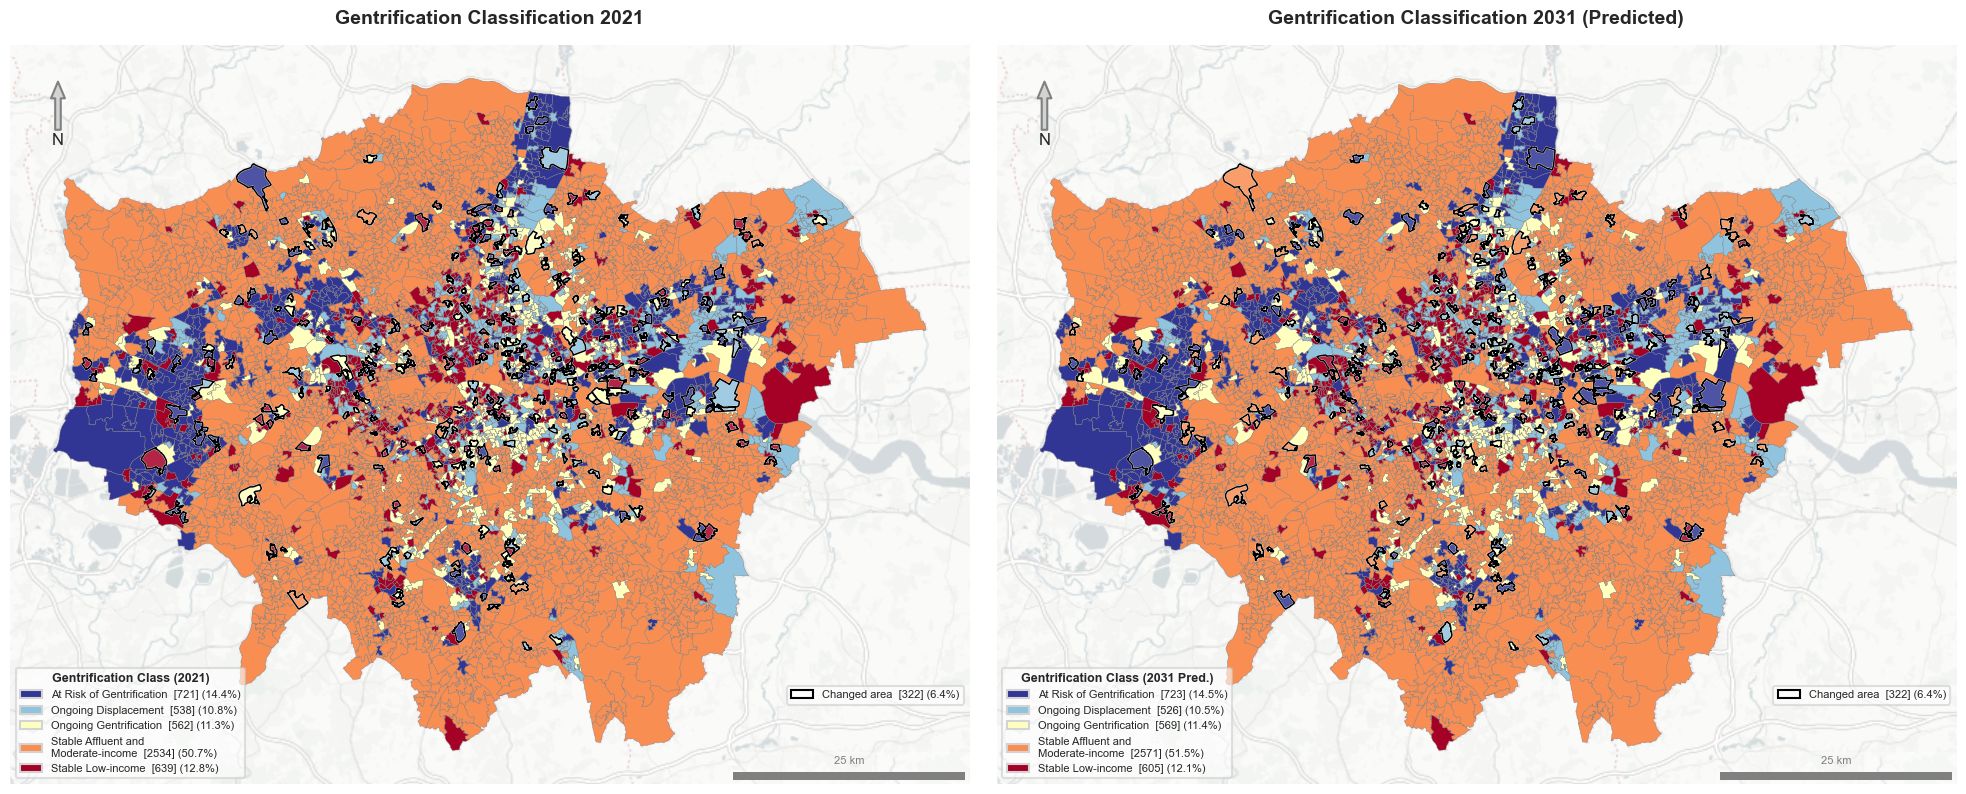

In [41]:
# Compare 2021 and 2031

def extract_after_dash(s: str) -> str:
    """Use the text after the first '-' as the semantic label."""
    if not isinstance(s, str):
        s = str(s)
    parts = s.split('-', 1)
    return parts[1].strip() if len(parts) > 1 else s.strip()

def wrap_label(s, width=26):
    """Wrap long legend labels for readability."""
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=False))

def build_label_color_map(labels_in_order, cmap_name="RdYlBu_r"):
    """Return dict: label -> color using a discrete, ordered palette."""
    K = len(labels_in_order)
    base = plt.get_cmap(cmap_name, K)
    return {lab: base(i) for i, lab in enumerate(labels_in_order)}

# -----------------------
# Load 2021 5-class labels from CSV
# -----------------------
df_2021 = pd.read_csv("../Output/Gentrification label_2021_5class.csv")
df_2021 = df_2021[["LSOA21CD", "gentrification_class"]].copy()
df_2021.rename(columns={"gentrification_class": "gentrification_class_2021"}, inplace=True)

# Ensure df_pred_2031 has expected columns
df_2031 = df_pred_2031[["LSOA21CD", "gentrification_class"]].copy()
df_2031.rename(columns={"gentrification_class": "gentrification_class_2031"}, inplace=True)

# -----------------------
# Merge onto base geometry and reproject to Web Mercator
# -----------------------
gdf_web_compare= gdf.merge(df_2021, on="LSOA21CD", how="left").merge(df_2031, on="LSOA21CD", how="left")
gdf_web_compare = gdf_web_compare.to_crs(epsg=3857).copy()

# Labels used for coloring: text after '-'
gdf_web_compare["label_after_2021"] = gdf_web_compare["gentrification_class_2021"].astype(str).apply(extract_after_dash)
gdf_web_compare["label_after_2031"] = gdf_web_compare["gentrification_class_2031"].astype(str).apply(extract_after_dash)

# -----------------------
# Build a single master palette from the union of labels (stable alphabetical order)
# -----------------------
labels_union = pd.unique(
    pd.Series(pd.concat([gdf_web_compare["label_after_2021"], gdf_web_compare["label_after_2031"]], ignore_index=True)).dropna()
)
labels_in_order = sorted(labels_union)
label2color = build_label_color_map(labels_in_order, cmap_name="RdYlBu_r")

# Map labels to integer indices for plotting
lab2idx = {lab: i for i, lab in enumerate(labels_in_order)}
gdf_web_compare["__idx__2021"] = gdf_web_compare["label_after_2021"].map(lab2idx)
gdf_web_compare["__idx__2031"] = gdf_web_compare["label_after_2031"].map(lab2idx)
cmap = ListedColormap([label2color[lab] for lab in labels_in_order])

# -----------------------
# Detect changed areas (by semantic label-after-dash)
# -----------------------
changed_mask = (gdf_web_compare["label_after_2021"] != gdf_web_compare["label_after_2031"]) & \
               (gdf_web_compare["label_after_2021"].notna() | gdf_web_compare["label_after_2031"].notna())
changed_gdf_2021 = gdf_web_compare.loc[changed_mask, ["LSOA21CD", "geometry"]].copy()
changed_gdf_2031 = changed_gdf_2021.copy()  # same set of LSOAs in both panels

# -----------------------
# Prepare figure
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor="white")
for ax in axes:
    ax.set_facecolor("#f7f7f7")  # subtle neutral background

# Basemap (Carto Light without labels)
carto_light_url = "https://cartodb-basemaps-a.global.ssl.fastly.net/light_nolabels/{z}/{x}/{y}{r}.png"
basemap_alpha = 1.0

# North arrow placement (axis coordinates)
nx, ny, nlen = 0.05, 0.95, 0.08

# -----------------------
# Left panel: 2021 (5-class)
# -----------------------
ax = axes[0]
gdf_web_compare.plot(
    ax=ax,
    column="__idx__2021",
    cmap=cmap,
    linewidth=0.3,
    edgecolor="grey",
    legend=False,
    zorder=1
)

# Highlight overlay (changed areas)
if not changed_gdf_2021.empty:
    changed_gdf_2021.plot(ax=ax, facecolor=(1, 1, 1, 0.15), edgecolor='none', zorder=7)
    changed_gdf_2021.boundary.plot(ax=ax, color='white', linewidth=1.5, zorder=8)
    changed_gdf_2021.boundary.plot(ax=ax, color="#000000", linewidth=1.1, zorder=9)

# Basemap, title, scale bar, north arrow
ctx.add_basemap(ax, source=carto_light_url, alpha=basemap_alpha)
ax.set_title("Gentrification Classification 2021", fontsize=14, fontweight="bold", pad=15)
ax.axis("off")
ax.add_artist(ScaleBar(dx=1, units="m", dimension="si-length",
                       location="lower right", length_fraction=0.25,
                       scale_loc="top", box_alpha=0.25, color="grey",
                       font_properties={"size": 8}))
ax.annotate("N", xy=(nx, ny), xytext=(nx, ny - nlen), xycoords=ax.transAxes,
            arrowprops=dict(facecolor="lightgrey", edgecolor="grey", width=4, headwidth=10),
            ha="center", va="center", fontsize=12)

# Legend 1 (categories) for left panel
denom_2021 = gdf_web_compare["label_after_2021"].notna().sum()
counts_2021 = gdf_web_compare["label_after_2021"].value_counts(dropna=False)
cat_handles_left = []
for lab in labels_in_order:
    cnt = int(counts_2021.get(lab, 0))
    pct = (cnt / denom_2021 * 100.0) if denom_2021 > 0 else 0.0
    label_txt = f"{wrap_label(lab)}  [{cnt}] ({pct:.1f}%)"
    cat_handles_left.append(Patch(facecolor=label2color[lab], edgecolor="lightgrey", label=label_txt))
leg1_left = ax.legend(
    handles=cat_handles_left,
    title="Gentrification Class (2021)",
    fontsize=8,
    title_fontsize=9,
    loc="lower left",
    frameon=True
)
leg1_left.get_frame().set_alpha(0.6)
leg1_left.get_title().set_fontweight('bold')
ax.add_artist(leg1_left)  # keep when adding second legend

# Legend 2 (changed areas) for left panel
if not changed_gdf_2021.empty:
    changed_cnt = len(changed_gdf_2021)
    changed_pct = (changed_cnt / len(gdf_web_compare)) * 100.0 if len(gdf_web_compare) > 0 else 0.0
    changed_label = f"Changed area  [{changed_cnt}] ({changed_pct:.1f}%)"
    changed_patch = Patch(facecolor=(1, 1, 1, 0.15), edgecolor="#000000", label=changed_label)
    leg2_left = ax.legend(handles=[changed_patch], fontsize=8, loc="lower right",
                          bbox_to_anchor=(1, 0.1), frameon=True)
    leg2_left.get_frame().set_alpha(0.6)

# -----------------------
# Right panel: 2031 (Predicted)
# -----------------------
ax = axes[1]
gdf_web_compare.plot(
    ax=ax,
    column="__idx__2031",
    cmap=cmap,
    linewidth=0.3,
    edgecolor="grey",
    legend=False,
    zorder=1
)

# Same changed-area mask
if not changed_gdf_2031.empty:
    changed_gdf_2031.plot(ax=ax, facecolor=(1, 1, 1, 0.15), edgecolor='none', zorder=7)
    changed_gdf_2031.boundary.plot(ax=ax, color='white', linewidth=1.5, zorder=8)
    changed_gdf_2031.boundary.plot(ax=ax, color="#000000", linewidth=1.1, zorder=9)

ctx.add_basemap(ax, source=carto_light_url, alpha=basemap_alpha)
ax.set_title("Gentrification Classification 2031 (Predicted)", fontsize=14, fontweight="bold", pad=15)
ax.axis("off")
ax.add_artist(ScaleBar(dx=1, units="m", dimension="si-length",
                       location="lower right", length_fraction=0.25,
                       scale_loc="top", box_alpha=0.25, color="grey",
                       font_properties={"size": 8}))
ax.annotate("N", xy=(nx, ny), xytext=(nx, ny - nlen), xycoords=ax.transAxes,
            arrowprops=dict(facecolor="lightgrey", edgecolor="grey", width=4, headwidth=10),
            ha="center", va="center", fontsize=12)

# Legend 1 (categories) for right panel
denom_2031 = gdf_web_compare["label_after_2031"].notna().sum()
counts_2031 = gdf_web_compare["label_after_2031"].value_counts(dropna=False)
cat_handles_right = []
for lab in labels_in_order:
    cnt = int(counts_2031.get(lab, 0))
    pct = (cnt / denom_2031 * 100.0) if denom_2031 > 0 else 0.0
    label_txt = f"{wrap_label(lab)}  [{cnt}] ({pct:.1f}%)"
    cat_handles_right.append(Patch(facecolor=label2color[lab], edgecolor="lightgrey", label=label_txt))
leg1_right = ax.legend(
    handles=cat_handles_right,
    title="Gentrification Class (2031 Pred.)",
    fontsize=8,
    title_fontsize=9,
    loc="lower left",
    frameon=True
)
leg1_right.get_frame().set_alpha(0.6)
leg1_right.get_title().set_fontweight('bold')
ax.add_artist(leg1_right)

# Legend 2 (changed areas) for right panel
if not changed_gdf_2031.empty:
    changed_cnt = len(changed_gdf_2031)
    changed_pct = (changed_cnt / len(gdf_web_compare)) * 100.0 if len(gdf_web_compare) > 0 else 0.0
    changed_label = f"Changed area  [{changed_cnt}] ({changed_pct:.1f}%)"
    changed_patch = Patch(facecolor=(1, 1, 1, 0.15), edgecolor="#000000", label=changed_label)
    leg2_right = ax.legend(handles=[changed_patch], fontsize=8, loc="lower right",
                           bbox_to_anchor=(1, 0.1), frameon=True)
    leg2_right.get_frame().set_alpha(0.6)

plt.tight_layout()
plt.show()

Changed areas: 322 / 4,994 (6.4%)


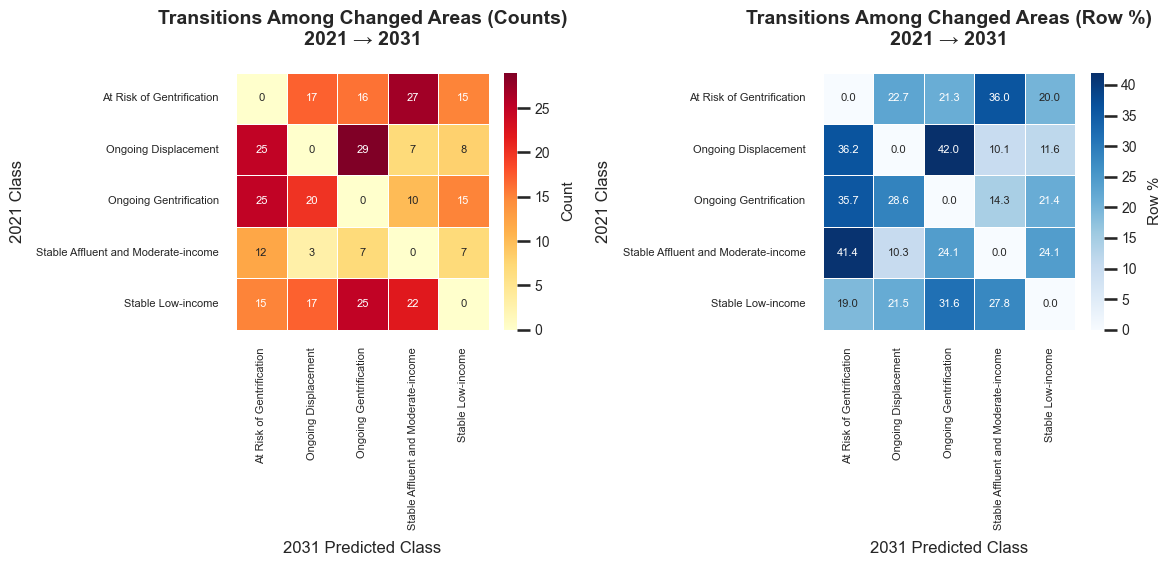

In [42]:
def extract_after_dash(s: str) -> str:
    """Extract the semantic label after the first dash."""
    if not isinstance(s, str):
        s = str(s)
    parts = s.split('-', 1)
    return parts[1].strip() if len(parts) > 1 else s.strip()

# -----------------------
# Merge + extract semantic labels
# -----------------------
df = (
    df_2021.merge(df_2031, on="LSOA21CD", how="inner")
    .assign(
        label_after_2021=lambda x: x["gentrification_class_2021"].astype(str).apply(extract_after_dash),
        label_after_2031=lambda x: x["gentrification_class_2031"].astype(str).apply(extract_after_dash)
    )
)

# Only changed areas
df_changed = df.loc[
    (df["label_after_2021"] != df["label_after_2031"]) &
    (df["label_after_2021"].notna() | df["label_after_2031"].notna())
].copy()

print(f"Changed areas: {len(df_changed):,} / {len(df):,} ({len(df_changed)/len(df)*100:.1f}%)")

# -----------------------
# Class ordering (union of labels in both years)
# -----------------------
labels_order = sorted(pd.unique(pd.concat([df["label_after_2021"], df["label_after_2031"]]).dropna()))

# -----------------------
# Transition matrix: counts
# -----------------------
ctab_counts = pd.crosstab(
    df_changed["label_after_2021"],
    df_changed["label_after_2031"]
).reindex(index=labels_order, columns=labels_order, fill_value=0)

# Transition matrix: row percentages
row_sums = ctab_counts.sum(axis=1).replace(0, np.nan)
ctab_row_pct = (ctab_counts.div(row_sums, axis=0) * 100).fillna(0)

# -----------------------
# Plot side-by-side heatmaps
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Counts heatmap
hm0=sns.heatmap(
    ctab_counts,
    annot=True, fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Count"},
    annot_kws={"size": 8},
    ax=axes[0]
)
axes[0].set_title("Transitions Among Changed Areas (Counts)\n2021 → 2031", fontsize=14)
axes[0].set_xlabel("2031 Predicted Class", fontsize=12)
axes[0].set_ylabel("2021 Class", fontsize=12)
axes[0].tick_params(axis='x', labelsize=8)  # X-axis tick font size
axes[0].tick_params(axis='y', labelsize=8)  # Y-axis tick font size

cbar0 = hm0.collections[0].colorbar
cbar0.ax.tick_params(labelsize=10)
cbar0.set_label("Count", fontsize=11)

# Row % heatmap
hm1=sns.heatmap(
    ctab_row_pct,
    annot=True, fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Row %"},
    annot_kws={"size": 8},
    ax=axes[1]
)
axes[1].set_title("Transitions Among Changed Areas (Row %)\n2021 → 2031", fontsize=14)
axes[1].set_xlabel("2031 Predicted Class", fontsize=12)
axes[1].set_ylabel("2021 Class", fontsize=12)
axes[1].tick_params(axis='x', labelsize=8)  # X-axis tick font size
axes[1].tick_params(axis='y', labelsize=8)  # Y-axis tick font size

cbar1 = hm1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=10)
cbar1.set_label("Row %", fontsize=11)

plt.tight_layout()
plt.show()